### Example for using saved hdf5 RIXS spectra

Name of RIXS spectra saved: Data variables:
    0        (points, variable) float64 58kB ...
    1        (points, variable) float64 58kB ...
    2        (points, variable) float64 58kB ...
    3        (points, variable) float64 58kB ...
    4        (points, variable) float64 58kB ...
    5        (points, variable) float64 58kB ...
    6        (points, variable) float64 58kB ...
dict_keys(['mirror', 'x_name', 'y_name', 'norm_name', 'filename', 'run', 'H', 'K', 'L', 'th', 'chi', 'phi', 'tth', 'energy', 'x', 'y', 'z', 'T', 'calibration', 'normalization_divide_value'])
-0.010000669281780844
-2.2227558891798618e-17
Energy Loss (eV)
2
1.1610096816376299
(2400,)
(2400,)


Text(0, 0.5, 'Intensity (a.u.)')

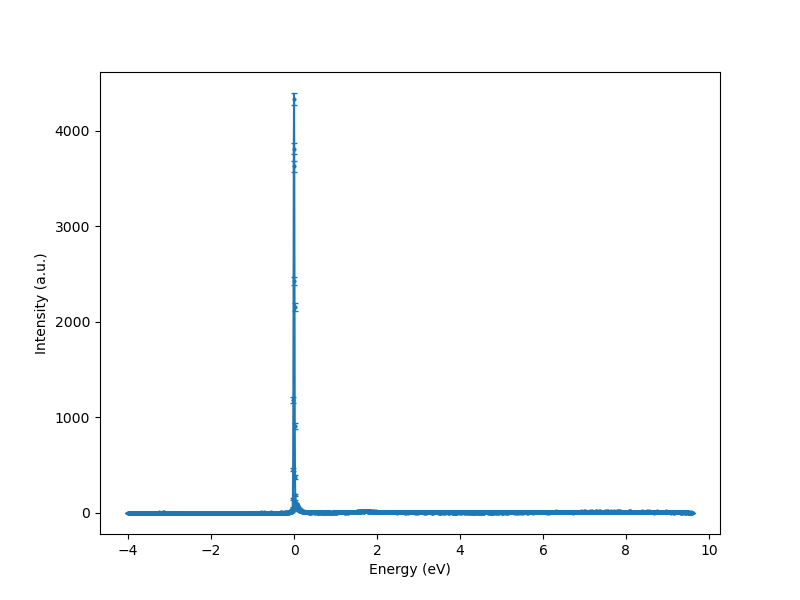

In [ ]:
%matplotlib widget

import os
import sys
import xarray as xr
import matplotlib.pyplot as plt

filepath = r"C:\Users\leona\OneDrive - Universität Zürich UZH\LQMR group - HC-6552\data_extraction_trial\DSO_Emap_H0p20.hdf5"
with xr.open_dataset(filepath, engine='h5netcdf') as ds:
    #Each xarray Dataset contains several DataArrays, each representing a different RIXS spectrum
    print(f"Name of RIXS spectra saved: {ds.data_vars}")

    da = ds['0']   #this is a DataArray. It contains "variables" (energy, rixs, error) and "attributes" (metadata)

    #The energy loss, SPC, and error will be saved in variables 'x', 'y', 'error'.
    #you can retrieve the names in attributes 'x_name', 'y_name', respectively.
    energy = da.sel(variable='x').values
    rixs = da.sel(variable='y').values
    error = da.sel(variable='error').values

    print(da.attrs.keys())
    print(da.attrs['H'])
    print(da.attrs['K'])
    print(da.attrs['x_name'])
    print(da.attrs['run'])
    print(da.attrs['mirror'])


print(energy.shape)
print(rixs.shape)
plt.figure(figsize=(8, 6))
plt.errorbar(energy, rixs, error, fmt='o-', markersize=2, capsize=2, label='RIXS Spectrum')
plt.xlabel('Energy (eV)')
plt.ylabel('Intensity (a.u.)')


